# Análisis de la condición financiera de Apple Inc.

*Sección de informe · perspectiva de analista financiero (nivel CFA / Corporate Finance).*

Este análisis evalúa la salud financiera de Apple Inc. utilizando **exclusivamente** la
información de su **Formulario 10-K (año fiscal 2025, cerrado el 27-sep-2025)** y su
**Formulario 10-Q (2.º trimestre fiscal 2026, cerrado el 28-mar-2026)**.

**Alcance de los datos.** El 10-K presenta el Estado de Resultados y el Flujo de Efectivo
de **tres años (FY2023–FY2025)** y el Balance de **dos años (FY2024–FY2025)**. Por eso los
ratios que dependen del balance se calculan para **FY2025 y FY2024 con saldos de cierre**
(no promedios), para que ambos años sean comparables. Cifras en **millones de dólares**
salvo indicación en contrario; el año fiscal de Apple termina a fines de septiembre.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Datos tomados EXCLUSIVAMENTE del 10-K (FY2025) y 10-Q (Q2-2026) de Apple.
# Cifras en US$ millones salvo EPS y ratios. FY termina fin de septiembre.
# ============================================================
IS = {  # Estado de Resultados (10-K)
    2025: dict(rev=416161, cogs=220960, gross=195201, opex=62151, opinc=133050,
               oie=-321, pretax=132729, tax=20719, ni=112010, eps_d=7.46,
               prod=307003, serv=109158, sh_d=15004697),
    2024: dict(rev=391035, cogs=210352, gross=180683, opex=57467, opinc=123216,
               oie=269, pretax=123485, tax=29749, ni=93736, eps_d=6.08,
               prod=294866, serv=96169, sh_d=15408095),
    2023: dict(rev=383285, cogs=214137, gross=169148, opex=54847, opinc=114301,
               oie=-565, pretax=113736, tax=16741, ni=96995, eps_d=6.13,
               prod=298085, serv=85200, sh_d=15812547),
}
BS = {  # Balance (el 10-K reporta 2 años)
    2025: dict(cash=35934, msc=18763, ar=39777, inv=5718, ca=147957, ppe=49834,
               msnc=77723, ta=359241, ap=69860, cp=7979, tdc=12350, cl=165631,
               tdn=78328, tl=285508, eq=73733),
    2024: dict(cash=29943, msc=35228, ar=33410, inv=7286, ca=152987, ppe=45680,
               msnc=91479, ta=364980, ap=68960, cp=9967, tdc=10912, cl=176392,
               tdn=85750, tl=308030, eq=56950),
}
CF = {  # Flujo de Efectivo (10-K)
    2025: dict(ocf=111482, da=11698, sbc=12863, capex=12715, div=15421, buyback=90711, taxpaid=43369),
    2024: dict(ocf=118254, da=11445, sbc=11688, capex=9447, div=15234, buyback=94949, taxpaid=26102),
    2023: dict(ocf=110543, da=11519, sbc=10833, capex=10959, div=15025, buyback=77550, taxpaid=18679),
}
for y in BS: BS[y]["debt"] = BS[y]["cp"] + BS[y]["tdc"] + BS[y]["tdn"]
for y in CF: CF[y]["fcf"]  = CF[y]["ocf"] - CF[y]["capex"]

caja_val = BS[2025]["cash"] + BS[2025]["msc"] + BS[2025]["msnc"]
print("Deuda total 2025/2024:", BS[2025]["debt"], "/", BS[2024]["debt"])
print("Caja+valores 2025:", caja_val, "| Caja NETA:", caja_val - BS[2025]["debt"])

Deuda total 2025/2024: 98657 / 106629
Caja+valores 2025: 132420 | Caja NETA: 33763


## 1. Resumen de estados financieros

Principales rubros de los tres estados, con su variación anual (%).

In [2]:
# Estado de Resultados (FY2023-2025)
rub = [("Ingresos totales","rev"),("Costo de ventas","cogs"),("Utilidad bruta","gross"),
       ("Gastos operativos","opex"),("Utilidad operativa","opinc"),
       ("Utilidad antes de impuestos","pretax"),("Provision de impuestos","tax"),
       ("Utilidad neta","ni"),("EPS diluido (US$)","eps_d")]
rows=[]
for n,k in rub:
    v=[IS[y][k] for y in (2025,2024,2023)]
    fmt=(lambda z:f"{z:,.2f}") if k=="eps_d" else (lambda z:f"{z:,.0f}")
    rows.append({"Rubro":n,"FY2025":fmt(v[0]),"FY2024":fmt(v[1]),"FY2023":fmt(v[2]),
                 "Δ 25/24":f"{(v[0]/v[1]-1)*100:+.1f}%","Δ 24/23":f"{(v[1]/v[2]-1)*100:+.1f}%"})
pd.DataFrame(rows)

,Rubro,FY2025,FY2024,FY2023,Δ 25/24,Δ 24/23
0,Ingresos totales,"416,161","391,035","383,285",+6.4%,+2.0%
1,Costo de ventas,"220,960","210,352","214,137",+5.0%,-1.8%
2,Utilidad bruta,"195,201","180,683","169,148",+8.0%,+6.8%
3,Gastos operativos,"62,151","57,467","54,847",+8.2%,+4.8%
4,Utilidad operativa,"133,050","123,216","114,301",+8.0%,+7.8%
5,Utilidad antes de impuestos,"132,729","123,485","113,736",+7.5%,+8.6%
6,Provision de impuestos,"20,719","29,749","16,741",-30.4%,+77.7%
7,Utilidad neta,"112,010","93,736","96,995",+19.5%,-3.4%
8,EPS diluido (US$),7.46,6.08,6.13,+22.7%,-0.8%


In [3]:
# Balance General (FY2024-2025)
rub=[("Efectivo y equivalentes","cash"),("Valores negociables (corr.)","msc"),
     ("Cuentas por cobrar","ar"),("Inventarios","inv"),("Activo corriente","ca"),
     ("Prop., planta y equipo neto","ppe"),("Valores negociables (no corr.)","msnc"),
     ("Activos totales","ta"),("Cuentas por pagar","ap"),("Pasivo corriente","cl"),
     ("Deuda total con intereses","debt"),("Pasivos totales","tl"),("Patrimonio","eq")]
rows=[]
for n,k in rub:
    v25,v24=BS[2025][k],BS[2024][k]
    rows.append({"Rubro":n,"FY2025":f"{v25:,.0f}","FY2024":f"{v24:,.0f}","Δ 25/24":f"{(v25/v24-1)*100:+.1f}%"})
pd.DataFrame(rows)

,Rubro,FY2025,FY2024,Δ 25/24
0,Efectivo y equivalentes,"35,934","29,943",+20.0%
1,Valores negociables (corr.),"18,763","35,228",-46.7%
2,Cuentas por cobrar,"39,777","33,410",+19.1%
3,Inventarios,"5,718","7,286",-21.5%
4,Activo corriente,"147,957","152,987",-3.3%
5,"Prop., planta y equipo neto","49,834","45,680",+9.1%
6,Valores negociables (no corr.),"77,723","91,479",-15.0%
7,Activos totales,"359,241","364,980",-1.6%
8,Cuentas por pagar,"69,860","68,960",+1.3%
9,Pasivo corriente,"165,631","176,392",-6.1%


In [4]:
# Flujo de Efectivo (FY2023-2025)
rub=[("Flujo operativo (OCF)","ocf"),("Depreciacion y amortizacion","da"),
     ("Comp. basada en acciones","sbc"),("CapEx (compra de PP&E)","capex"),
     ("Flujo de caja libre (FCF)","fcf"),("Dividendos pagados","div"),
     ("Recompras de acciones","buyback"),("Impuestos pagados en efectivo","taxpaid")]
rows=[]
for n,k in rub:
    v=[CF[y][k] for y in (2025,2024,2023)]
    rows.append({"Rubro":n,"FY2025":f"{v[0]:,.0f}","FY2024":f"{v[1]:,.0f}","FY2023":f"{v[2]:,.0f}",
                 "Δ 25/24":f"{(v[0]/v[1]-1)*100:+.1f}%"})
pd.DataFrame(rows)

,Rubro,FY2025,FY2024,FY2023,Δ 25/24
0,Flujo operativo (OCF),"111,482","118,254","110,543",-5.7%
1,Depreciacion y amortizacion,"11,698","11,445","11,519",+2.2%
2,Comp. basada en acciones,"12,863","11,688","10,833",+10.1%
3,CapEx (compra de PP&E),"12,715","9,447","10,959",+34.6%
4,Flujo de caja libre (FCF),"98,767","108,807","99,584",-9.2%
5,Dividendos pagados,"15,421","15,234","15,025",+1.2%
6,Recompras de acciones,"90,711","94,949","77,550",-4.5%
7,Impuestos pagados en efectivo,"43,369","26,102","18,679",+66.2%


## 2. Análisis horizontal

Crecimiento anual (%) de las cuentas principales.

In [5]:
h_is=[("Revenue","rev"),("Gross Profit","gross"),("Operating Income","opinc"),
      ("Net Income","ni"),("EPS Diluted","eps_d")]
h_bs=[("Total Assets","ta"),("Cash & Equivalents","cash"),("Current Assets","ca"),
      ("Total Liabilities","tl"),("Current Liabilities","cl"),("Shareholders Equity","eq")]
rows=[]
for n,k in h_is:
    rows.append({"Cuenta":n,"Estado":"Resultados",
                 "Crec. 25/24":f"{(IS[2025][k]/IS[2024][k]-1)*100:+.1f}%",
                 "Crec. 24/23":f"{(IS[2024][k]/IS[2023][k]-1)*100:+.1f}%"})
for n,k in h_bs:
    rows.append({"Cuenta":n,"Estado":"Balance",
                 "Crec. 25/24":f"{(BS[2025][k]/BS[2024][k]-1)*100:+.1f}%","Crec. 24/23":"n/d"})
pd.DataFrame(rows)

,Cuenta,Estado,Crec. 25/24,Crec. 24/23
0,Revenue,Resultados,+6.4%,+2.0%
1,Gross Profit,Resultados,+8.0%,+6.8%
2,Operating Income,Resultados,+8.0%,+7.8%
3,Net Income,Resultados,+19.5%,-3.4%
4,EPS Diluted,Resultados,+22.7%,-0.8%
5,Total Assets,Balance,-1.6%,n/d
6,Cash & Equivalents,Balance,+20.0%,n/d
7,Current Assets,Balance,-3.3%,n/d
8,Total Liabilities,Balance,-7.3%,n/d
9,Current Liabilities,Balance,-6.1%,n/d


**Tendencias clave:**

- **Ingresos** aceleran a **+6.4 %** en FY2025 (desde +2.0 %), impulsados por
  **Servicios (+13.5 %)** frente a Productos (+4.1 %): el negocio de mayor margen es el
  motor de crecimiento.
- **Utilidad bruta (+8.0 %)** y **operativa (+8.0 %)** crecen por encima de los ingresos
  → expansión de márgenes.
- La **utilidad neta salta +19.5 %**, pero eso exagera el desempeño: la utilidad *antes
  de impuestos* creció solo **+7.5 %**. El salto se debe a que la tasa impositiva efectiva
  bajó de **24.1 % (FY2024)** a **15.6 % (FY2025)** —FY2024 tuvo un cargo fiscal
  extraordinario—.
- El **EPS diluido (+22.7 %)** crece aún más que la utilidad neta porque las **recompras**
  redujeron las acciones ~2.6 %.
- En el **balance**, activos −1.6 % y pasivos −7.3 %, mientras el **patrimonio sube
  +29.5 %**: Apple achica su balance y reconstruye patrimonio (el déficit acumulado se
  estrecha).

## 3. Análisis vertical (common size)

In [6]:
# Estado de Resultados como % de Ingresos
rows=[]
for etq,k in [("Gross Margin","gross"),("Operating Expenses","opex"),
              ("Operating Margin","opinc"),("Net Margin","ni")]:
    rows.append({"% de Revenue":etq,
                 "FY2025":f"{IS[2025][k]/IS[2025]['rev']*100:.1f}%",
                 "FY2024":f"{IS[2024][k]/IS[2024]['rev']*100:.1f}%",
                 "FY2023":f"{IS[2023][k]/IS[2023]['rev']*100:.1f}%"})
pd.DataFrame(rows)

,% de Revenue,FY2025,FY2024,FY2023
0,Gross Margin,46.9%,46.2%,44.1%
1,Operating Expenses,14.9%,14.7%,14.3%
2,Operating Margin,32.0%,31.5%,29.8%
3,Net Margin,26.9%,24.0%,25.3%


In [7]:
# Balance como % de Activos Totales
rows=[]
for etq,k in [("Cash","cash"),("Inventories","inv"),("Property, Plant & Equipment","ppe"),
              ("Total Debt","debt"),("Total Liabilities","tl"),("Equity","eq")]:
    rows.append({"% de Activos":etq,
                 "FY2025":f"{BS[2025][k]/BS[2025]['ta']*100:.1f}%",
                 "FY2024":f"{BS[2024][k]/BS[2024]['ta']*100:.1f}%"})
pd.DataFrame(rows)

,% de Activos,FY2025,FY2024
0,Cash,10.0%,8.2%
1,Inventories,1.6%,2.0%
2,"Property, Plant & Equipment",13.9%,12.5%
3,Total Debt,27.5%,29.2%
4,Total Liabilities,79.5%,84.4%
5,Equity,20.5%,15.6%


**Cambios relevantes:**

- **Resultados:** el **margen bruto se expandió de 44.1 % (FY2023) a 46.9 % (FY2025)**
  (+2.8 pts) por la mayor participación de Servicios. El **margen operativo** subió a
  **32.0 %** y el neto a **26.9 %** (FY2024, 24.0 %, quedó deprimido por impuestos).
- **Balance:** Apple es **muy poco intensiva en activos**: inventarios apenas **1.6 %** y
  PP&E **13.9 %**. La caja subió a **10.0 %**. Los **pasivos son 79.5 %** de los activos y
  el **patrimonio solo 20.5 %** (sube desde 15.6 %): patrimonio contable delgado por años
  de recompras. La deuda con intereses baja a **27.5 %** de los activos.

## 4. Razones financieras (CFA)

Ratios calculados con saldos de cierre. Formato: indicador · fórmula · cálculo (FY2025) ·
resultado FY2025 · FY2024 · interpretación.

### Liquidez

| Indicador | Fórmula | Cálculo (FY2025) | FY2025 | FY2024 | Interpretación |
|---|---|---|---:|---:|---|
| Current Ratio | Activo corr. / Pasivo corr. | 147,957 / 165,631 | 0.89 | 0.87 | <1, pero sano dado el ciclo de conversión negativo |
| Quick Ratio | (Caja + Valores + CxC) / Pasivo corr. | (35,934+18,763+39,777) / 165,631 | 0.57 | 0.56 | Activos líquidos cubren ~57 % del pasivo corriente |
| Cash Ratio | (Caja + Valores) / Pasivo corr. | (35,934+18,763) / 165,631 | 0.33 | 0.37 | Solo caja y valores cubren 1/3 del pasivo corriente |

### Solvencia

| Indicador | Fórmula | Cálculo (FY2025) | FY2025 | FY2024 | Interpretación |
|---|---|---|---:|---:|---|
| Debt to Assets | Deuda total / Activos | 98,657 / 359,241 | 0.27 | 0.29 | Solo 27 % de los activos se financia con deuda |
| Debt to Equity | Deuda total / Patrimonio | 98,657 / 73,733 | 1.34 | 1.87 | Alto, pero por patrimonio contable reducido (recompras) |
| Financial Leverage | Activos / Patrimonio | 359,241 / 73,733 | 4.87 | 6.41 | Apalancamiento cae al reconstruirse el patrimonio |
| Interest Coverage | Utilidad operativa / Gasto por intereses | 133,050 / ~2,900* | ~46x | ~44x | Cobertura enorme; los intereses son insignificantes |

\* El gasto por intereses no se desglosa (queda dentro de *Other income/(expense), net*). Se estima con el pago de intereses de la deuda que el 10-K reporta (~USD 2.6 mil M de los *Notes* + ~USD 0.3 mil M de papel comercial).

### Rentabilidad

| Indicador | Fórmula | Cálculo (FY2025) | FY2025 | FY2024 | Interpretación |
|---|---|---|---:|---:|---|
| Gross Margin | Utilidad bruta / Ingresos | 195,201 / 416,161 | 46.9 % | 46.2 % | Margen bruto en expansión (mezcla de Servicios) |
| Operating Margin | Utilidad operativa / Ingresos | 133,050 / 416,161 | 32.0 % | 31.5 % | Rentabilidad operativa excepcional |
| Net Margin | Utilidad neta / Ingresos | 112,010 / 416,161 | 26.9 % | 24.0 % | FY24 deprimido por impuestos; FY25 normaliza |
| ROA | Utilidad neta / Activos | 112,010 / 359,241 | 31.2 % | 25.7 % | Retorno sobre activos altísimo |
| ROE | Utilidad neta / Patrimonio | 112,010 / 73,733 | 151.9 % | 164.6 % | Inflado por el patrimonio contable reducido |
| ROIC | NOPAT / (Deuda + Patrimonio) | 112,281 / 172,390 | 65.1 % | 57.2 % | Retorno sobre capital invertido sobresaliente |

### Eficiencia

| Indicador | Fórmula | Cálculo (FY2025) | FY2025 | FY2024 | Interpretación |
|---|---|---|---:|---:|---|
| Asset Turnover | Ingresos / Activos | 416,161 / 359,241 | 1.16 | 1.07 | Genera 1.16 USD de ventas por USD de activo |
| Inventory Turnover | Costo de ventas / Inventario | 220,960 / 5,718 | 38.6x | 28.9x | Rotación de inventario extrema (cadena esbelta) |
| Receivables Turnover | Ingresos / CxC | 416,161 / 39,777 | 10.5x | 11.7x | Cobra ~10–12 veces al año |
| Days Sales Outstanding | 365 / Rotación CxC | 365 / 10.5 | 34.9 d | 31.2 d | Cobra en ~35 días |
| Days Inventory Outstanding | 365 / Rotación inventario | 365 / 38.6 | 9.4 d | 12.6 d | Inventario dura ~9 días |
| Cash Conversion Cycle | DIO + DSO − DPO | 9.4 + 34.9 − 115.4 | −71 d | −76 d | **Negativo:** los proveedores financian el capital de trabajo |

*(DPO = 365 / (Costo de ventas / Cuentas por pagar) = 365 / (220,960/69,860) = 115.4 días.)*

### Flujo de Caja

| Indicador | Fórmula | Cálculo (FY2025) | FY2025 | FY2024 | Interpretación |
|---|---|---|---:|---:|---|
| OCF / Net Income | Flujo operativo / Utilidad neta | 111,482 / 112,010 | 1.00 | 1.26 | Utilidades respaldadas por caja |
| Free Cash Flow | OCF − CapEx | 111,482 − 12,715 | 98,767 | 108,807 | ~USD 99 mil M de caja libre |
| FCF Margin | FCF / Ingresos | 98,767 / 416,161 | 23.7 % | 27.8 % | Casi 1/4 de las ventas se vuelve caja libre |
| Capital Expenditures | Compra de PP&E | — | 12,715 | 9,447 | CapEx bajo (~3 % de ventas): negocio poco intensivo en capital |

## 5. Calidad de las utilidades

- **Utilidad neta vs. flujo operativo:** el OCF iguala o supera la utilidad neta cada año
  —**OCF/NI = 1.00 (FY2025), 1.26 (FY2024), 1.14 (FY2023)**—. Las utilidades están
  respaldadas por caja, no por devengos agresivos.
- **El descenso a 1.00 en FY2025 es explicable:** los **impuestos pagados en efectivo
  saltaron a USD 43.4 mil M** (desde USD 26.1 mil M), reflejando el desembolso del cargo
  fiscal extraordinario reconocido en FY2024. Ajustando ese pago único, la conversión de
  caja sigue siendo sobresaliente.
- **Flujo de caja libre** enorme y estable: **USD 98.8 / 108.8 / 99.6 mil M** en
  FY2025/24/23, con **margen de FCF de ~24–28 %**.
- **Retorno de capital:** recompras de **USD 90.7 mil M** y dividendos de **USD 15.4 mil M**
  en FY2025 (~USD 106 mil M en total), por encima del FCF del año; Apple complementa con su
  caja, lo que explica la contracción del balance. Autorizó un nuevo programa de recompras
  de **USD 100 mil M** (mayo 2025).
- **Capital de trabajo:** en FY2025 hubo consumo de caja por cuentas por cobrar y por el
  pago de pasivos fiscales, compensado en parte por la liberación de inventarios.

**Interpretación:** la utilidad es de **alta calidad y sostenible** —respaldada por caja, con
devengos bajos y necesidades de inversión mínimas—.

## 6. Estructura de capital

- **Evolución de la deuda:** la deuda con intereses **bajó a USD 98.7 mil M** (FY2025)
  desde USD 106.6 mil M (FY2024); en el año Apple repagó ~USD 10.9 mil M de deuda a plazo y
  redujo el papel comercial.
- **Composición corto/largo plazo:** predomina el **largo plazo** —deuda no corriente
  USD 78.3 mil M (~79 % de la deuda)— sobre el corto plazo (papel comercial USD 8.0 mil M +
  porción corriente USD 12.4 mil M). Vencimientos bien escalonados.
- **Patrimonio:** sube **+29.5 %** a USD 73.7 mil M al estrecharse el déficit acumulado.
- **Impacto de las recompras:** años de recompras masivas mantienen el **patrimonio
  contable pequeño** frente a la capitalización de mercado (~USD 4.9 billones), lo que
  **infla el ROE (152 %) y el D/E (1.34)**.
- **Apalancamiento:** el D/E cayó de 1.87 a 1.34 y el multiplicador de activos de 6.4x a
  4.9x; la deuda es solo **27 % de los activos**.

**Punto clave:** con **USD 132.4 mil M en caja y valores frente a USD 98.7 mil M de deuda,
Apple mantiene una posición de CAJA NETA (~USD 34 mil M)**. En términos netos la estructura
es **conservadora** (cobertura de intereses estimada ~46x); la política de recompras la hace
*agresiva desde la óptica del accionista*, pero los ratios contables lucen apalancados por
diseño, no por fragilidad financiera.

## 7. Riesgos financieros

Según el MD&A y las notas del 10-K/10-Q:

- **Liquidez:** sólida. USD 132.4 mil M en caja y valores y ~USD 111 mil M de flujo
  operativo anual cubren con holgura las obligaciones. Existen, no obstante, compromisos
  materiales a 12 meses: **obligaciones de compra de manufactura USD 55.4 mil M**, deuda por
  USD 12.4 mil M y el impuesto de repatriación (TCJA) de USD 8.8 mil M. El current ratio <1
  se compensa con el ciclo de conversión negativo y el enorme flujo operativo.
- **Tipo de cambio:** Apple es receptor neto de monedas distintas al dólar; un dólar fuerte
  reduce ventas y márgenes. Mitiga con forwards y swaps de divisas; su modelo VAR estima una
  pérdida diaria máxima de ~USD 590 M en las posiciones de derivados FX.
- **Tasas de interés:** afectan el valor de su portafolio de inversión y el costo de su
  deuda. Un alza de +100 pb elevaría el gasto anual por intereses en ~USD 129 M y reduciría
  el valor razonable del portafolio en ~USD 2.4 mil M. Usa swaps de tasa.
- **Concentración de ingresos:** dependencia del **iPhone** y de pocos clientes; las cuentas
  por cobrar comerciales se concentran en operadoras de telefonía y revendedores, y las
  cuentas por cobrar a proveedores en unos pocos vendedores de Asia.
- **Cadena de suministro:** producción tercerizada en socios de ensamblaje y **componentes
  de fuente única o limitada**, con **concentración geográfica en Asia**; USD 56.2 mil M en
  obligaciones de compra de manufactura.
- **Riesgo regulatorio:** exposición a leyes cambiantes y complejas a nivel mundial
  (competencia/antimonopolio, privacidad y protección de datos) y a cambios tributarios
  (Irlanda, Singapur, TCJA, tributación mínima global).

## 8. Interpretación de resultados — evaluación para inversionistas

**¿Posición financiera sólida?** Sí, de forma contundente. Apple combina una rentabilidad de
primer nivel (margen operativo del 32 % y neto del 27 %) con una generación de caja
excepcional (flujo operativo de ~USD 111 mil M y flujo libre de ~USD 99 mil M en FY2025). Su
retorno sobre el capital invertido (ROIC ~65 %) evidencia una ventaja competitiva duradera y
un uso muy eficiente del capital.

**¿Liquidez adecuada?** Sí, con un matiz. Los ratios estáticos parecen ajustados —current
ratio de 0.89 y quick ratio de 0.57, ambos por debajo de 1—, lo que en otra empresa
encendería alertas. En Apple, sin embargo, el **ciclo de conversión de efectivo es negativo
(~−71 días)**: cobra a sus clientes y rota su inventario mucho antes de pagar a sus
proveedores, de modo que estos financian su capital de trabajo. Sumado a USD 132 mil M en
caja y valores y a un flujo operativo inmenso, la liquidez es holgada.

**¿El endeudamiento representa un riesgo?** No en términos económicos. Aunque el D/E (1.34) y
el multiplicador de apalancamiento (4.9x) lucen elevados, obedecen a un **patrimonio contable
deliberadamente reducido por años de recompras**, no a fragilidad. Apple mantiene **más
efectivo y valores (USD 132 mil M) que deuda (USD 99 mil M)** —posición de caja neta— y una
cobertura de intereses estimada superior a 40 veces. El apalancamiento es una decisión de
estructura de capital eficiente, no una vulnerabilidad.

**¿Rentabilidad consistente?** Sí. Los márgenes se han expandido de forma sostenida (bruto de
44.1 % a 46.9 % en dos años), apoyados en la creciente participación de los **Servicios**, de
mayor margen y más recurrentes. El salto del 19.5 % en la utilidad neta de FY2025 está algo
inflado por la normalización de la tasa impositiva tras el cargo extraordinario de FY2024; la
tendencia operativa subyacente (utilidad operativa +8 %) es sólida.

**¿Los flujos de caja respaldan las utilidades?** Sí. El flujo operativo iguala o supera la
utilidad neta cada año (OCF/NI ≈ 1.0–1.3), señal de utilidades de alta calidad con devengos
bajos.

**Fortalezas:** márgenes y ROIC excepcionales, generación de caja masiva, balance con caja
neta, cadena de suministro ultraeficiente y retorno de capital agresivo pero financiado con
caja propia.

**Debilidades y vigilancia:** alta concentración en el iPhone y en proveedores asiáticos,
exposición regulatoria y antimonopolio creciente, sensibilidad al tipo de cambio, y un
patrimonio contable delgado que magnifica los ratios de apalancamiento. En conjunto, **Apple
presenta una posición financiera muy sólida**, con una calidad de utilidades y una liquidez
económica que respaldan holgadamente su perfil de riesgo.

## 10. Gráficos

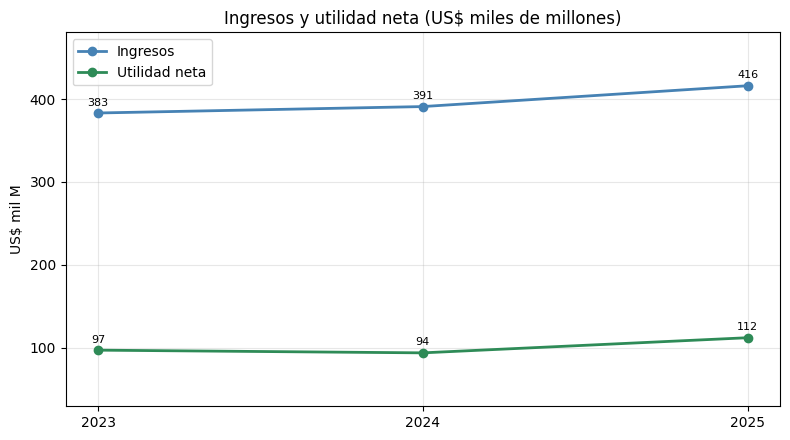

In [8]:
# Grafico 1: Ingresos vs Utilidad neta
años=[2023,2024,2025]
rev_s=[IS[y]["rev"]/1000 for y in años]; ni_s=[IS[y]["ni"]/1000 for y in años]
fig,ax=plt.subplots(figsize=(8,4.5))
ax.plot(años,rev_s,marker="o",color="steelblue",lw=2,label="Ingresos")
ax.plot(años,ni_s,marker="o",color="seagreen",lw=2,label="Utilidad neta")
for x,y in zip(años,rev_s): ax.text(x,y+9,f"{y:.0f}",ha="center",fontsize=8)
for x,y in zip(años,ni_s): ax.text(x,y+9,f"{y:.0f}",ha="center",fontsize=8)
ax.set_title("Ingresos y utilidad neta (US$ miles de millones)")
ax.set_xticks(años); ax.set_ylabel("US$ mil M"); ax.legend(); ax.grid(alpha=0.3)
ax.margins(y=0.2); plt.tight_layout(); plt.show()

Los ingresos crecieron de USD 383 a 416 mil M en dos años, con aceleración en
FY2025. La utilidad neta subió a USD 112 mil M; su mayor pendiente en el último año refleja
tanto la expansión de márgenes como la normalización de la tasa impositiva tras el cargo de
FY2024.

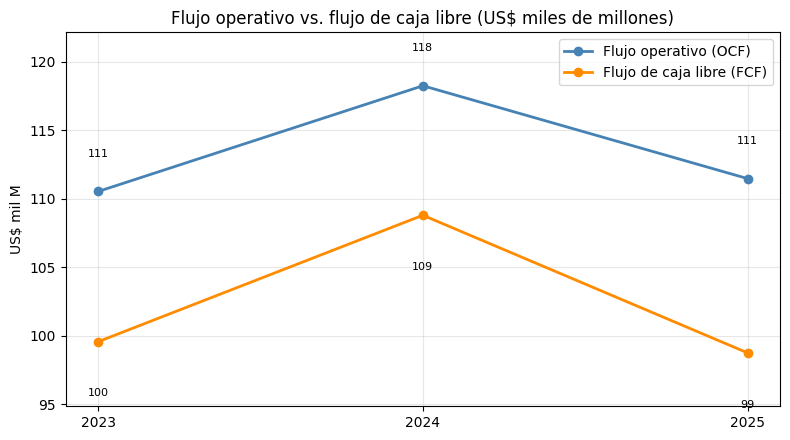

In [9]:
# Grafico 2: Flujo operativo vs Flujo de caja libre
ocf_s=[CF[y]["ocf"]/1000 for y in años]; fcf_s=[CF[y]["fcf"]/1000 for y in años]
fig,ax=plt.subplots(figsize=(8,4.5))
ax.plot(años,ocf_s,marker="o",color="steelblue",lw=2,label="Flujo operativo (OCF)")
ax.plot(años,fcf_s,marker="o",color="darkorange",lw=2,label="Flujo de caja libre (FCF)")
for x,y in zip(años,ocf_s): ax.text(x,y+2.5,f"{y:.0f}",ha="center",fontsize=8)
for x,y in zip(años,fcf_s): ax.text(x,y-4,f"{y:.0f}",ha="center",fontsize=8)
ax.set_title("Flujo operativo vs. flujo de caja libre (US$ miles de millones)")
ax.set_xticks(años); ax.set_ylabel("US$ mil M"); ax.legend(); ax.grid(alpha=0.3)
ax.margins(y=0.2); plt.tight_layout(); plt.show()

El flujo operativo y el libre se mantienen altísimos y estables (~USD 99–118
mil M). El descenso del OCF en FY2025 responde al desembolso extraordinario de impuestos en
efectivo, no a un deterioro del negocio. La brecha OCF–FCF es pequeña: Apple invierte poco
(~3 % de ventas).

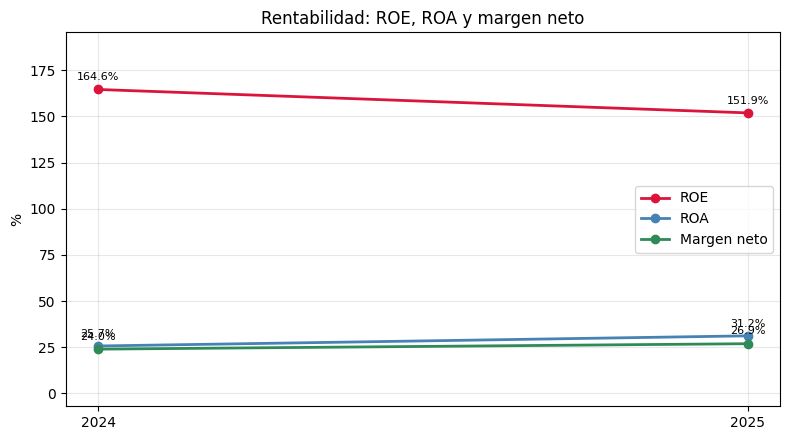

In [10]:
# Grafico 3: ROE, ROA y Margen neto (ROE/ROA solo 2024-2025 por disponibilidad del balance)
yb=[2024,2025]
roe=[IS[y]["ni"]/BS[y]["eq"]*100 for y in yb]; roa=[IS[y]["ni"]/BS[y]["ta"]*100 for y in yb]
nm=[IS[y]["ni"]/IS[y]["rev"]*100 for y in yb]
fig,ax=plt.subplots(figsize=(8,4.5))
ax.plot(yb,roe,marker="o",lw=2,color="crimson",label="ROE")
ax.plot(yb,roa,marker="o",lw=2,color="steelblue",label="ROA")
ax.plot(yb,nm,marker="o",lw=2,color="seagreen",label="Margen neto")
for s in (roe,roa,nm):
    for x,y in zip(yb,s): ax.text(x,y+5,f"{y:.1f}%",ha="center",fontsize=8)
ax.set_title("Rentabilidad: ROE, ROA y margen neto")
ax.set_xticks(yb); ax.set_ylabel("%"); ax.legend(); ax.grid(alpha=0.3)
ax.margins(y=0.22); plt.tight_layout(); plt.show()

La rentabilidad es sobresaliente y creciente en ROA (25.7 %→31.2 %) y margen
neto (24.0 %→26.9 %). El ROE, altísimo (~150–165 %), está inflado por el patrimonio contable
reducido; su leve descenso se debe al aumento del patrimonio, no a menor rentabilidad.

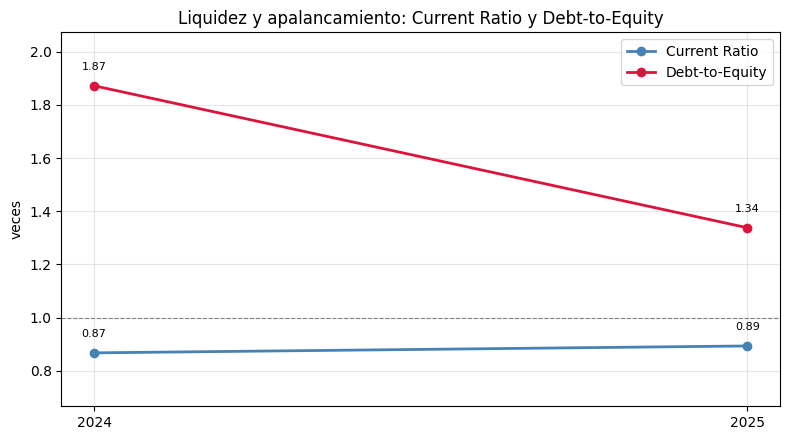

In [11]:
# Grafico 4: Current Ratio y Debt-to-Equity
cr=[BS[y]["ca"]/BS[y]["cl"] for y in yb]; de=[BS[y]["debt"]/BS[y]["eq"] for y in yb]
fig,ax=plt.subplots(figsize=(8,4.5))
ax.plot(yb,cr,marker="o",lw=2,color="steelblue",label="Current Ratio")
ax.plot(yb,de,marker="o",lw=2,color="crimson",label="Debt-to-Equity")
for s in (cr,de):
    for x,y in zip(yb,s): ax.text(x,y+0.06,f"{y:.2f}",ha="center",fontsize=8)
ax.axhline(1.0,color="gray",ls="--",lw=0.8)
ax.set_title("Liquidez y apalancamiento: Current Ratio y Debt-to-Equity")
ax.set_xticks(yb); ax.set_ylabel("veces"); ax.legend(); ax.grid(alpha=0.3)
ax.margins(y=0.2); plt.tight_layout(); plt.show()

El current ratio se mantiene estable, apenas por debajo de 1 —sostenible por el
ciclo de conversión negativo—. El Debt-to-Equity bajó de 1.87 a 1.34 al reconstruirse el
patrimonio y reducirse la deuda: la empresa se desapalanca en términos contables.

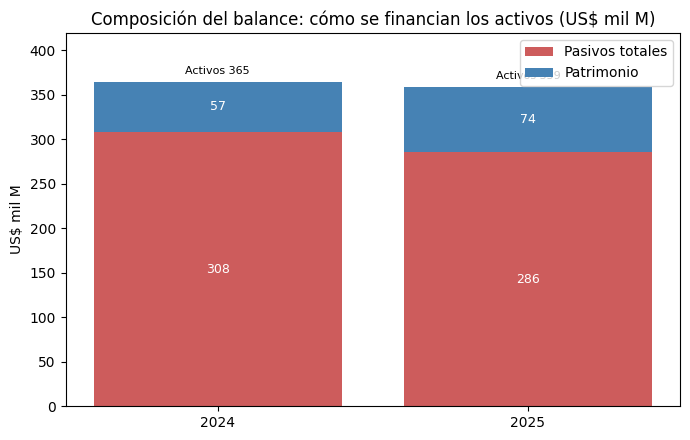

In [12]:
# Grafico 5: Composición del balance (Pasivos + Patrimonio = Activos)
labels=[str(y) for y in yb]; liab=[BS[y]["tl"]/1000 for y in yb]; equ=[BS[y]["eq"]/1000 for y in yb]
fig,ax=plt.subplots(figsize=(7,4.5))
ax.bar(labels,liab,color="indianred",label="Pasivos totales")
ax.bar(labels,equ,bottom=liab,color="steelblue",label="Patrimonio")
for i,y in enumerate(yb):
    ax.text(i,liab[i]/2,f"{liab[i]:.0f}",ha="center",va="center",color="white",fontsize=9)
    ax.text(i,liab[i]+equ[i]/2,f"{equ[i]:.0f}",ha="center",va="center",color="white",fontsize=9)
    ax.text(i,liab[i]+equ[i]+9,f"Activos {liab[i]+equ[i]:.0f}",ha="center",fontsize=8)
ax.set_title("Composición del balance: cómo se financian los activos (US$ mil M)")
ax.set_ylabel("US$ mil M"); ax.legend(); ax.margins(y=0.15)
plt.tight_layout(); plt.show()

Los activos se financian mayoritariamente con pasivos, pero la porción de
patrimonio crece (de USD 57 a 74 mil M) mientras los pasivos totales caen (de USD 308 a 286
mil M). El balance se hace más pequeño y algo menos apalancado año contra año.